<a href="https://colab.research.google.com/github/riyamotwanii/AML-Assignments/blob/main/Exp_5_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATASET HEAD ==========

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

========== DATASET INFO ==========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 

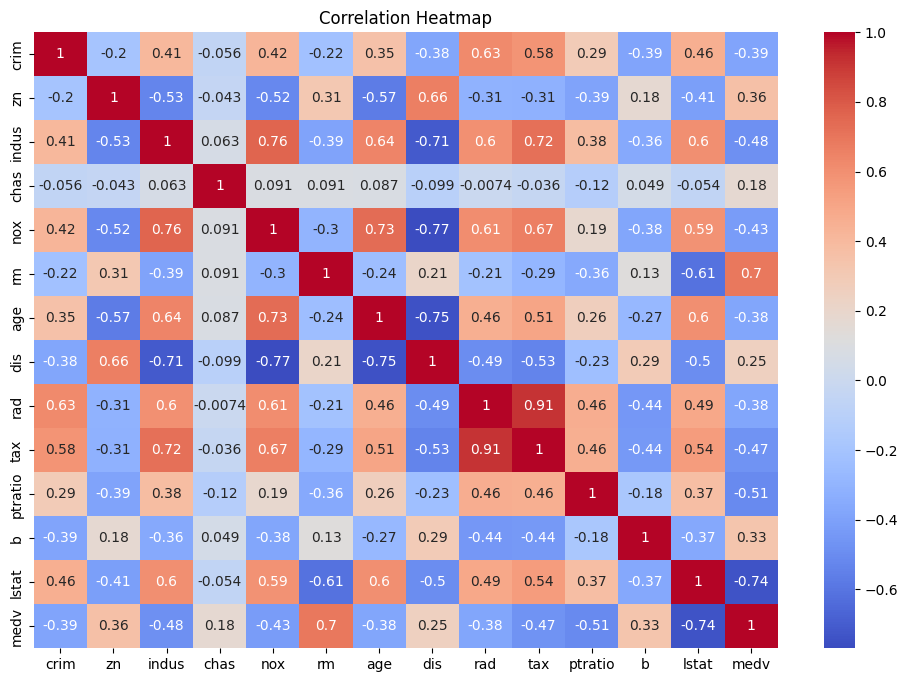

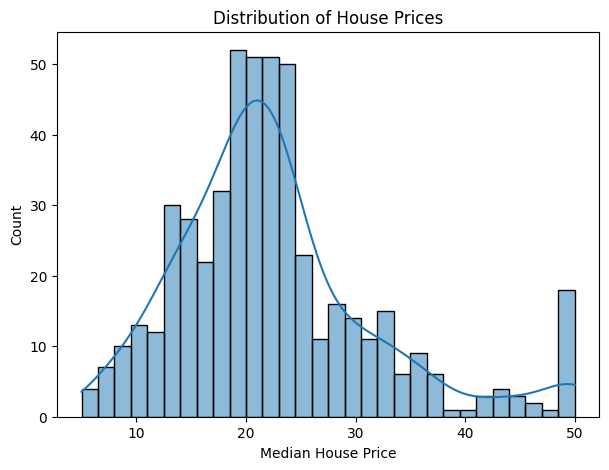


========== DATASET SHAPE AFTER OUTLIER REMOVAL ==========

(268, 14)

MODEL : Linear Regression
MAE : 1.515
MSE : 3.728
R2 Score : 0.783

MODEL : Decision Tree Regressor
MAE : 2.254
MSE : 7.742
R2 Score : 0.549

MODEL : Random Forest Regressor
MAE : 1.553
MSE : 4.297
R2 Score : 0.75

MODEL : Gradient Boosting Regressor
MAE : 1.536
MSE : 4.097
R2 Score : 0.762

========== MODEL COMPARISON ==========

                         Model       MAE       MSE  R2 Score
0            Linear Regression  1.515158  3.728132  0.783067
1      Decision Tree Regressor  2.253704  7.742407  0.549483
2      Random Forest Regressor  1.552833  4.296923  0.749970
3  Gradient Boosting Regressor  1.536085  4.097200  0.761591

========== BEST PERFORMING MODEL ==========

Model       Linear Regression
MAE                  1.515158
MSE                  3.728132
R2 Score             0.783067
Name: 0, dtype: object

========== FEATURE IMPORTANCE ==========

    Feature  Importance
12    lstat    0.435392
5        rm

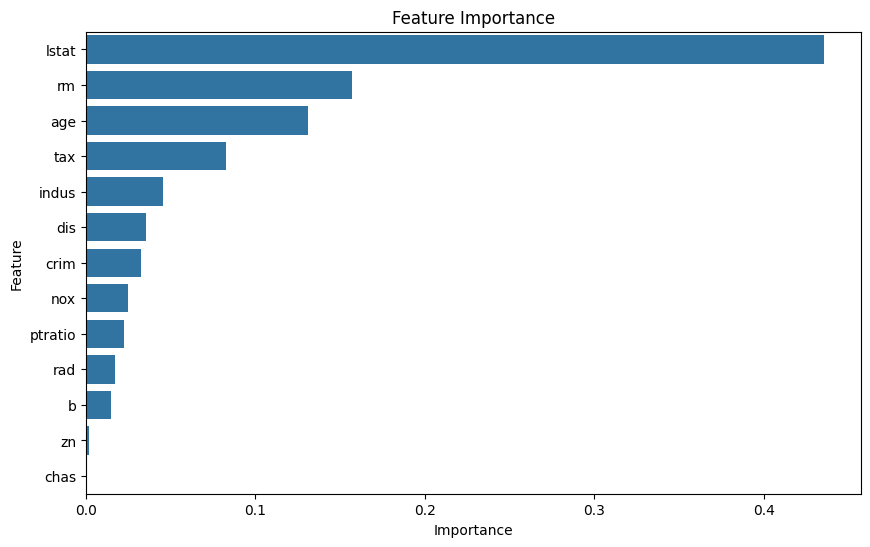


FINAL CONCLUSION

1. Multiple regression models were trained.
2. Models were evaluated using MAE, MSE, and R2 Score.
3. The model with highest R2 score is considered best.
4. Feature importance shows which factors affect prices most.
5. Random Forest and Gradient Boosting generally perform better.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')



url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print("========== DATASET HEAD ==========\n")
print(df.head())

# ============================================================
# STEP 3 : BASIC INFORMATION
# ============================================================

print("\n========== DATASET INFO ==========\n")
print(df.info())

print("\n========== DATASET SHAPE ==========\n")
print(df.shape)

print("\n========== STATISTICAL SUMMARY ==========\n")
print(df.describe())



print("\n========== MISSING VALUES ==========\n")
print(df.isnull().sum())

# ============================================================
# STEP 5 : EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Distribution of House Prices
plt.figure(figsize=(7,5))

sns.histplot(df['medv'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Price")

plt.show()

# ============================================================
# STEP 6 : HANDLE OUTLIERS
# ============================================================

# Using IQR Method

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

# Remove Outliers
df_clean = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("\n========== DATASET SHAPE AFTER OUTLIER REMOVAL ==========\n")
print(df_clean.shape)

# ============================================================
# STEP 7 : FEATURES AND TARGET
# ============================================================

X = df_clean.drop('medv', axis=1)

y = df_clean['medv']

# ============================================================
# STEP 8 : TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 9 : FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# STEP 10 : TRAIN MULTIPLE REGRESSION MODELS
# ============================================================

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42
    )
}

results = []

# ============================================================
# STEP 11 : MODEL TRAINING AND EVALUATION
# ============================================================

for name, model in models.items():

    print("\n================================================")
    print("MODEL :", name)
    print("================================================")

    # Linear Regression needs scaling
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    # Evaluation Metrics
    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    print("MAE :", round(mae, 3))
    print("MSE :", round(mse, 3))
    print("R2 Score :", round(r2, 3))

    results.append([name, mae, mse, r2])

# ============================================================
# STEP 12 : COMPARE MODEL PERFORMANCE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'MSE', 'R2 Score']
)

print("\n========== MODEL COMPARISON ==========\n")
print(results_df)

# ============================================================
# STEP 13 : IDENTIFY BEST MODEL
# ============================================================

best_model = results_df.loc[
    results_df['R2 Score'].idxmax()
]

print("\n========== BEST PERFORMING MODEL ==========\n")
print(best_model)

# ============================================================
# STEP 14 : FEATURE IMPORTANCE
# ============================================================

# Using Random Forest Feature Importance

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========\n")
print(feature_importance)

# ============================================================
# STEP 15 : FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n================================================")
print("FINAL CONCLUSION")
print("================================================\n")

print("1. Multiple regression models were trained.")
print("2. Models were evaluated using MAE, MSE, and R2 Score.")
print("3. The model with highest R2 score is considered best.")
print("4. Feature importance shows which factors affect prices most.")
print("5. Random Forest and Gradient Boosting generally perform better.")